# LSTM para secuencias PaySim

La LSTM conserva el orden dentro de cada secuencia.

## Protocolo comun de evaluacion

Este notebook usa tres conjuntos separados: **64% entrenamiento, 16% validacion y 20% prueba**. Validacion sirve para seleccionar el umbral y, cuando aplica, detener el entrenamiento. Prueba se usa una sola vez para las metricas finales.

Se reportan las mismas metricas en todos los modelos: ROC-AUC, PR-AUC, precision, recall, F1, TN, FP, FN, TP, tiempo de entrenamiento e inferencia. Tambien se guardan resultados con umbral 0.5 y con el umbral que maximiza F1 en validacion.

> La comparacion con modelos tabulares solo es directa si cada secuencia y cada fila tabular representan el mismo objetivo de prediccion.

## 1. Importaciones

In [1]:
from pathlib import Path
import json, platform, random, time, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (average_precision_score, classification_report, confusion_matrix,
 f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score,
 RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
warnings.filterwarnings('ignore')
RANDOM_STATE=42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)
print('Python:',platform.python_version(),'TensorFlow:',tf.__version__,'GPU:',tf.config.list_physical_devices('GPU'))


Python: 3.10.13 TensorFlow: 2.10.0 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuracion y modo de ejecucion

In [2]:
X_PATH=Path('datos_muestra/X_paysim_secuencias.npy')
Y_PATH=Path('datos_muestra/y_paysim_etiquetas.npy')
TEST_SIZE=.20
VALID_SIZE_FROM_TRAIN=.20
SPLIT_MODE='time'  # requiere que las secuencias esten ordenadas cronologicamente
BATCH_SIZE=512
EPOCHS=50
PATIENCE=7
OUTPUT_DIR=Path('resultados_lstm_paysim')
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_NAME='LSTM'
MODEL_PATH=OUTPUT_DIR/'mejor_modelo.keras'
LEGACY_H5_PATH=Path('modelo_fraude_lstm.h5')
# 'train': entrena arquitectura corregida; 'keras': carga mejor_modelo.keras; 'legacy_h5': carga tu H5 previo solo para analizarlo
RUN_MODE='train'
assert RUN_MODE in {'train','keras','legacy_h5'}


## 3. Carga de tensores

In [3]:
if not X_PATH.exists() or not Y_PATH.exists(): raise FileNotFoundError('Ajusta X_PATH/Y_PATH')
X=np.load(X_PATH,mmap_mode='r'); y=np.asarray(np.load(Y_PATH)).reshape(-1).astype('int8')
if X.ndim!=3 or len(X)!=len(y): raise ValueError('Se espera X=(muestras,pasos,variables) y un y por muestra')
if not np.isfinite(X).all(): raise ValueError('X contiene NaN o infinito')
seq_length,num_features=X.shape[1:]
print('X:',X.shape,'y:',y.shape,'fraude:',f'{y.mean():.6%}')


X: (6362620, 5, 9) y: (6362620,) fraude: 0.129082%


## 4. Particiones

In [4]:
idx=np.arange(len(y))
if SPLIT_MODE=='random':
    idx_tv,idx_test=train_test_split(idx,test_size=TEST_SIZE,stratify=y,random_state=RANDOM_STATE)
    idx_train,idx_valid=train_test_split(idx_tv,test_size=VALID_SIZE_FROM_TRAIN,stratify=y[idx_tv],random_state=RANDOM_STATE)
else:
    cut=int(len(idx)*(1-TEST_SIZE)); idx_tv,idx_test=idx[:cut],idx[cut:]
    cut2=int(len(idx_tv)*(1-VALID_SIZE_FROM_TRAIN)); idx_train,idx_valid=idx_tv[:cut2],idx_tv[cut2:]
X_train,y_train=np.asarray(X[idx_train]),y[idx_train]
X_valid,y_valid=np.asarray(X[idx_valid]),y[idx_valid]
X_test,y_test=np.asarray(X[idx_test]),y[idx_test]
for n,z in [('train',y_train),('valid',y_valid),('test',y_test)]: print(f'{n}: {len(z):,} | fraudes={int(z.sum()):,} | tasa={z.mean():.6%}')
assert all(np.unique(z).size==2 for z in (y_train,y_valid,y_test))
np.save(OUTPUT_DIR/'indices_train.npy',idx_train); np.save(OUTPUT_DIR/'indices_valid.npy',idx_valid); np.save(OUTPUT_DIR/'indices_test.npy',idx_test)
classes=np.array([0,1]); w=compute_class_weight('balanced',classes=classes,y=y_train); class_weights={0:float(w[0]),1:float(w[1])}
print('Pesos:',class_weights)


train: 4,072,076 | fraudes=5,272 | tasa=0.129467%
valid: 1,018,020 | fraudes=1,294 | tasa=0.127109%
test: 1,272,524 | fraudes=1,647 | tasa=0.129428%
Pesos: {0: 0.5006481748321286, 1: 386.198406676783}


## 5. Arquitectura

In [5]:
def build_model(seq_length,num_features):
    inputs=layers.Input((seq_length,num_features))
    x=layers.Masking(mask_value=0.0)(inputs)
    x=layers.LSTM(64,return_sequences=True)(x); x=layers.Dropout(.3)(x)
    x=layers.LSTM(32)(x); x=layers.Dropout(.3)(x)
    outputs=layers.Dense(1,activation='sigmoid')(x)
    m=tf.keras.Model(inputs,outputs,name='LSTM_fraude')
    m.compile(tf.keras.optimizers.Adam(1e-3),'binary_crossentropy',metrics=['accuracy',
      tf.keras.metrics.Precision(name='precision'),tf.keras.metrics.Recall(name='recall'),
      tf.keras.metrics.AUC(curve='ROC',name='auc_roc'),tf.keras.metrics.AUC(curve='PR',name='auc_pr')])
    return m


## 6. Entrenar o cargar modelo

In [ ]:
callbacks=[EarlyStopping(monitor='val_auc_pr',mode='max',patience=PATIENCE,restore_best_weights=True,verbose=1),
 ModelCheckpoint(MODEL_PATH,monitor='val_auc_pr',mode='max',save_best_only=True,verbose=1),
 ReduceLROnPlateau(monitor='val_auc_pr',mode='max',factor=.5,patience=3,min_lr=1e-6,verbose=1)]
training_seconds=None; history=None
if RUN_MODE=='train':
    model=build_model(seq_length,num_features)
    start=time.perf_counter(); history=model.fit(X_train,y_train,validation_data=(X_valid,y_valid),epochs=EPOCHS,
      batch_size=BATCH_SIZE,class_weight=class_weights,callbacks=callbacks,shuffle=False,verbose=1); training_seconds=time.perf_counter()-start
    model=tf.keras.models.load_model(MODEL_PATH,compile=False)
elif RUN_MODE=='keras':
    model=tf.keras.models.load_model(MODEL_PATH,compile=False)
else:
    if not LEGACY_H5_PATH.exists(): raise FileNotFoundError(f'No se encontro {LEGACY_H5_PATH}')
    model=tf.keras.models.load_model(LEGACY_H5_PATH,compile=False)
model.summary()
if history is not None:
    pd.DataFrame(history.history).to_csv(OUTPUT_DIR/'historial.csv',index_label='epoch')


Epoch 1/50
7954/7954 [==============================] - ETA: 0s - loss: 0.1025 - accuracy: 0.9690 - precision: 0.0390 - recall: 0.9695 - auc_roc: 0.9926 - auc_pr: 0.4804
Epoch 1: val_auc_pr improved from -inf to 0.74316, saving model to resultados_lstm_paysim\mejor_modelo.keras
7954/7954 [==============================] - 695s 86ms/step - loss: 0.1025 - accuracy: 0.9690 - precision: 0.0390 - recall: 0.9695 - auc_roc: 0.9926 - auc_pr: 0.4804 - val_loss: 0.0232 - val_accuracy: 0.9933 - val_precision: 0.1569 - val_recall: 0.9706 - val_auc_roc: 0.9983 - val_auc_pr: 0.7432 - lr: 0.0010
Epoch 2/50
7954/7954 [==============================] - ETA: 0s - loss: 0.0484 - accuracy: 0.9833 - precision: 0.0711 - recall: 0.9884 - auc_roc: 0.9968 - auc_pr: 0.5976
Epoch 2: val_auc_pr improved from 0.74316 to 0.82494, saving model to resultados_lstm_paysim\mejor_modelo.keras
7954/7954 [==============================] - 643s 81ms/step - loss: 0.0484 - accuracy: 0.9833 - precision: 0.0711 - recall: 0.9884

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



7954/7954 [==============================] - ETA: 0s - loss: 0.0395 - accuracy: 0.9884 - precision: 0.0996 - recall: 0.9913 - auc_roc: 0.9977 - auc_pr: 0.6430
Epoch 3: val_auc_pr did not improve from 0.82494
7954/7954 [==============================] - 1133s 142ms/step - loss: 0.0395 - accuracy: 0.9884 - precision: 0.0996 - recall: 0.9913 - auc_roc: 0.9977 - auc_pr: 0.6430 - val_loss: 0.0141 - val_accuracy: 0.9966 - val_precision: 0.2685 - val_recall: 0.9753 - val_auc_roc: 0.9988 - val_auc_pr: 0.7554 - lr: 0.0010
Epoch 4/50
 262/7954 [..............................] - ETA: 7:33 - loss: 0.0585 - accuracy: 0.9916 - precision: 0.1347 - recall: 0.9831 - auc_roc: 0.9952 - auc_pr: 0.6852

## 7. Probabilidades

In [7]:
start=time.perf_counter(); proba_valid=model.predict(X_valid,batch_size=BATCH_SIZE,verbose=1).ravel(); proba_test=model.predict(X_test,batch_size=BATCH_SIZE,verbose=1).ravel(); inference_seconds=time.perf_counter()-start


2486/2486 [==============================] - 10s 4ms/step


## 8. Metricas

In [8]:
def metricas(y_true,proba,threshold):
    pred=(proba>=threshold).astype(int); tn,fp,fn,tp=confusion_matrix(y_true,pred).ravel()
    return {'threshold':float(threshold),'roc_auc':float(roc_auc_score(y_true,proba)),
      'pr_auc':float(average_precision_score(y_true,proba)),
      'precision':float(precision_score(y_true,pred,zero_division=0)),
      'recall':float(recall_score(y_true,pred,zero_division=0)),
      'f1':float(f1_score(y_true,pred,zero_division=0)),
      'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}
def elegir_umbral(y_true,proba):
    p,r,t=precision_recall_curve(y_true,proba)
    f=2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]+1e-12)
    i=int(np.nanargmax(f)); return float(t[i]),float(f[i])
def sensibilidad(y_true,proba):
    rows=[]
    for u in np.round(np.arange(.05,1,.05),2):
        m=metricas(y_true,proba,u); rows.append(m)
    return pd.DataFrame(rows)


,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
umbral_0.5,0.500000,0.998889,0.96003,0.717460,0.960534,0.821391,1270254,623,65,1582
umbral_validacion,0.679762,0.998889,0.96003,0.873322,0.908318,0.890476,1270660,217,151,1496


Umbral elegido en validacion: 0.6797616481781006 | F1 validacion: 0.8950995405814295
              precision    recall  f1-score   support

           0     0.9999    0.9998    0.9999   1270877
           1     0.8733    0.9083    0.8905      1647

    accuracy                         0.9997   1272524
   macro avg     0.9366    0.9541    0.9452   1272524
weighted avg     0.9997    0.9997    0.9997   1272524



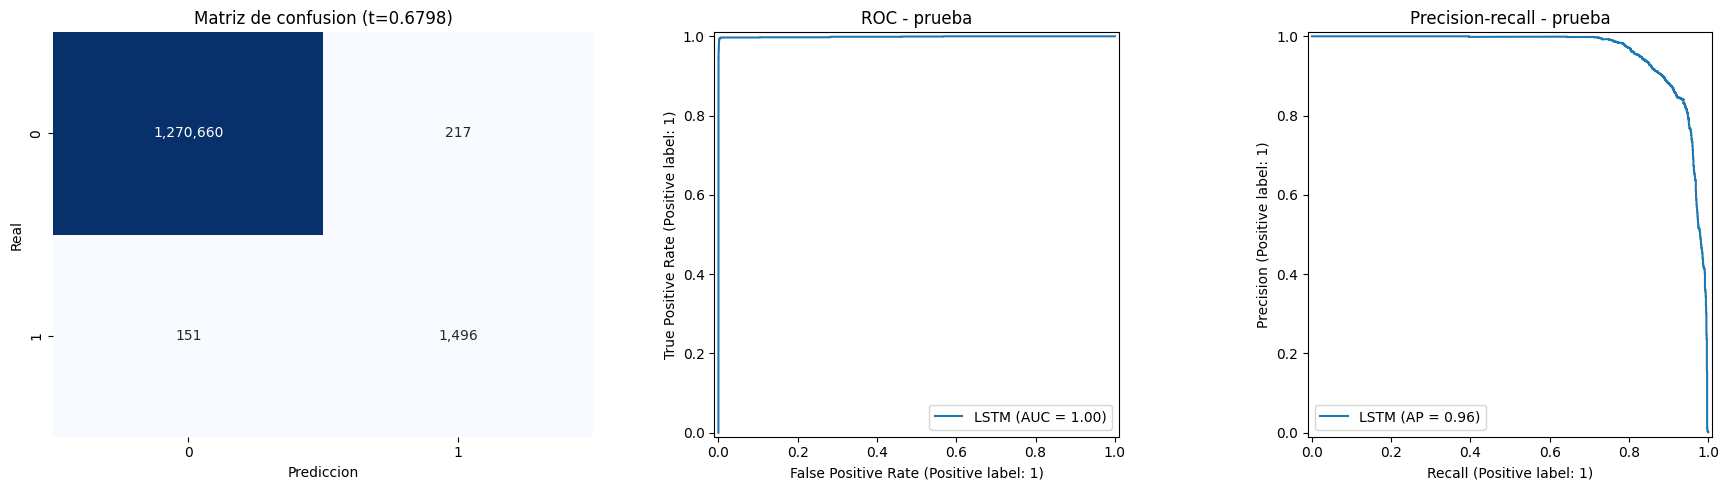

In [9]:
best_threshold,best_f1_valid=elegir_umbral(y_valid,proba_valid)
baseline=metricas(y_test,proba_test,.5)
tuned=metricas(y_test,proba_test,best_threshold)
comparison=pd.DataFrame([baseline,tuned],index=['umbral_0.5','umbral_validacion'])
display(comparison)
pred_test=(proba_test>=best_threshold).astype(int)
print('Umbral elegido en validacion:',best_threshold,'| F1 validacion:',best_f1_valid)
print(classification_report(y_test,pred_test,digits=4,zero_division=0))
fig,ax=plt.subplots(1,3,figsize=(18,5))
sns.heatmap(confusion_matrix(y_test,pred_test),annot=True,fmt=',d',cmap='Blues',cbar=False,ax=ax[0])
ax[0].set(title=f'Matriz de confusion (t={best_threshold:.4f})',xlabel='Prediccion',ylabel='Real')
RocCurveDisplay.from_predictions(y_test,proba_test,ax=ax[1],name=MODEL_NAME); ax[1].set_title('ROC - prueba')
PrecisionRecallDisplay.from_predictions(y_test,proba_test,ax=ax[2],name=MODEL_NAME); ax[2].set_title('Precision-recall - prueba')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'evaluacion_final.png',dpi=300,bbox_inches='tight'); plt.show()


## 9. Sensibilidad

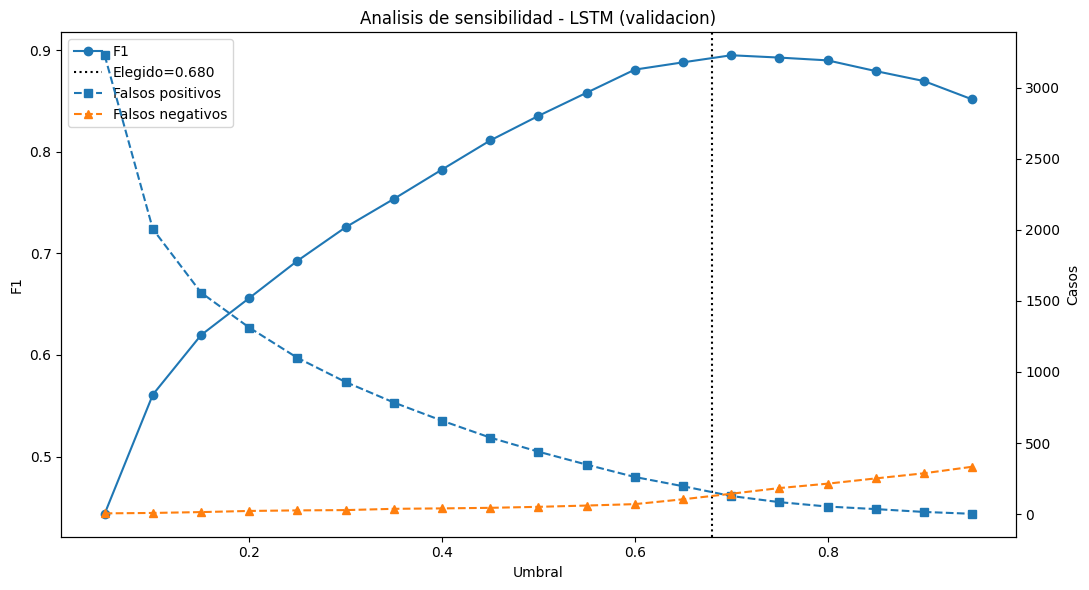

In [10]:
sens=sensibilidad(y_valid,proba_valid)
sens.to_csv(OUTPUT_DIR/'sensibilidad_validacion.csv',index=False)
fig,ax1=plt.subplots(figsize=(11,6))
l1,=ax1.plot(sens.threshold,sens.f1,marker='o',label='F1'); ax1.set(xlabel='Umbral',ylabel='F1')
ax1.axvline(best_threshold,color='black',linestyle=':',label=f'Elegido={best_threshold:.3f}')
ax2=ax1.twinx(); l2,=ax2.plot(sens.threshold,sens.fp,'--s',label='Falsos positivos'); l3,=ax2.plot(sens.threshold,sens.fn,'--^',label='Falsos negativos'); ax2.set_ylabel('Casos')
h1,labs1=ax1.get_legend_handles_labels(); h2,labs2=ax2.get_legend_handles_labels(); ax1.legend(h1+h2,labs1+labs2,loc='best')
plt.title(f'Analisis de sensibilidad - {MODEL_NAME} (validacion)'); fig.tight_layout()
plt.savefig(OUTPUT_DIR/'analisis_sensibilidad.png',dpi=300,bbox_inches='tight'); plt.show()


## 10. Exportacion

In [11]:
results={'model':MODEL_NAME,'data_unit':'secuencia','run_mode':RUN_MODE,'split_mode':SPLIT_MODE,
 'n_train':len(y_train),'n_valid':len(y_valid),'n_test':len(y_test),'sequence_length':int(seq_length),
 'num_features':int(num_features),'training_seconds':training_seconds,'inference_seconds':inference_seconds,
 'metrics_threshold_0_5':baseline,'metrics_threshold_validation':tuned}
json.dump(results,open(OUTPUT_DIR/'metricas.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
pd.DataFrame({'index_original':idx_test,'y_true':y_test,'probabilidad_fraude':proba_test,'prediccion':pred_test}).to_csv(OUTPUT_DIR/'predicciones_test.csv',index=False)
print('Guardado en',OUTPUT_DIR.resolve())


Guardado en C:\Users\alomi\Documentos\Unir\ProyectoFinal\notebooks_finales\resultados_lstm_paysim
